# Solver Benchmark — 2026-04-08

Running four solvers on matrices from `result_10000-2568220` (golf ball meshes, nv from ~10K to ~2.5M vertices).

**Two experiment groups:**
- `golf_ball_1` — single-threaded baseline (`OMP_NUM_THREADS=1` for OMP solvers, `mpirun -np 1` for MPI solvers)
- `golf_ball_8` — 8-way parallel (`OMP_NUM_THREADS=8` or `mpirun -np 8`)

**Solvers:**
- **AMGCL** — OMP-parallel iterative
- **Eigen::PardisoLDLT** — OMP-parallel direct (skipped for mat_sz > 727119, too slow)
- **Hypre_mpi** — MPI-parallel iterative (newly fixed: proper row partitioning + `MPI_Allgatherv`)
- **Trilinos** — MPI-parallel iterative

For each group we plot **elapse time vs matrix size (rows)** on log-log axes, with log-linear fit lines to show scaling slope.

In [14]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

sys.path.insert(0, '/u/1/chenyang/benchmark/analysis')
import libs.parser; importlib.reload(libs.parser)
from libs.parser import parse_log_file

SOLVER_COLORS = {
    "AMGCL":             "#d62728",
    "Eigen::PardisoLDLT": "#1f77b4",
    "Hypre_mpi":         "#2ca02c",
    "Trilinos":          "#ff7f0e",
}
# Longest prefix first so "Eigen::PardisoLDLT" matches before "Eigen::"
SOLVER_PREFIXES = sorted(SOLVER_COLORS.keys(), key=len, reverse=True)

# All matrices in this benchmark are stiffness matrices generated by PolyFEM
# with the Hessian projected to PSD (forced positive-definite for safe iterative solving).
DATA_SOURCE_NOTE = "Matrices: PolyFEM forced PSD"


def load_all_logs(log_dir):
    """Parse every *.log under log_dir, return DataFrame(solver, mat_sz, nnz, elapse_time)."""
    rows = []
    for fname in sorted(os.listdir(log_dir)):
        if not fname.endswith(".log"):
            continue
        solver = None
        for prefix in SOLVER_PREFIXES:
            if fname.startswith(prefix + "_"):
                solver = prefix
                break
        if solver is None:
            continue
        try:
            entries = parse_log_file(os.path.join(log_dir, fname), solver)
        except Exception as ex:
            print(f"Skipping {fname}: {ex}")
            continue
        for e in entries:
            if e.get("mat_sz") and e.get("elapse_time"):
                rows.append({
                    "solver":      solver,
                    "mat_sz":      e["mat_sz"],
                    "nnz":         e.get("nnz"),
                    "elapse_time": e["elapse_time"],
                    "num_iterations": e.get("num_iterations"),
                })
    return pd.DataFrame(rows)


def plot_time_vs_mat_sz(df, title, figsize=(10, 6)):
    """Scatter elapse_time vs mat_sz for each solver + log-log linear fit on per-mat_sz means."""
    fig, ax = plt.subplots(figsize=figsize)
    for solver in SOLVER_PREFIXES:
        g = df[df["solver"] == solver]
        if g.empty:
            continue
        color = SOLVER_COLORS[solver]
        ax.scatter(g["mat_sz"], g["elapse_time"], s=16, alpha=0.5, color=color,
                   label=f"{solver} (n={len(g)})")

        # Log-log linear fit on the AVERAGE elapse_time per distinct mat_sz
        g_mean = g.groupby("mat_sz")["elapse_time"].mean().reset_index().sort_values("mat_sz")
        if len(g_mean) >= 3:
            log_x = np.log10(g_mean["mat_sz"].values)
            log_y = np.log10(g_mean["elapse_time"].values)
            slope, intercept = np.polyfit(log_x, log_y, 1)
            x_fit = np.logspace(log_x.min(), log_x.max(), 200)
            y_fit = 10 ** (slope * np.log10(x_fit) + intercept)
            ax.plot(x_fit, y_fit, "--", color=color, linewidth=1.5, alpha=0.8,
                    label=f"  fit (slope={slope:.2f}, on means)")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Matrix Size (rows, log scale)", fontsize=12)
    ax.set_ylabel("Elapse Time (s, log scale)", fontsize=12)
    full_title = f"{title}\n{DATA_SOURCE_NOTE}  ·  fit lines = log-linear over mean elapse_time per mat_sz"
    ax.set_title(full_title, fontsize=11)
    ax.legend(fontsize=9, loc="upper left", ncol=2)
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    return fig, ax


BASE = '/u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-8/10000-2568220'
print(f"Base dir: {BASE}")
print(f"Groups: {sorted(os.listdir(BASE))}")

Base dir: /u/1/chenyang/benchmark_data/larger_matrix_exp/larger_mat_exp_result/2026-4-8/10000-2568220
Groups: ['golf_ball_1', 'golf_ball_8']


## Group 1: `golf_ball_1` — single-threaded baseline

Group golf_ball_1: 653 entries
                   mat_sz                elapse_time
                      min      max count        mean
solver                                              
AMGCL               29988  7704660   210  121.759576
Eigen::PardisoLDLT  29988   727119   144  337.403828
Hypre_mpi           29988  2890827   170  493.581412
Trilinos            29988   686154   129  702.404264


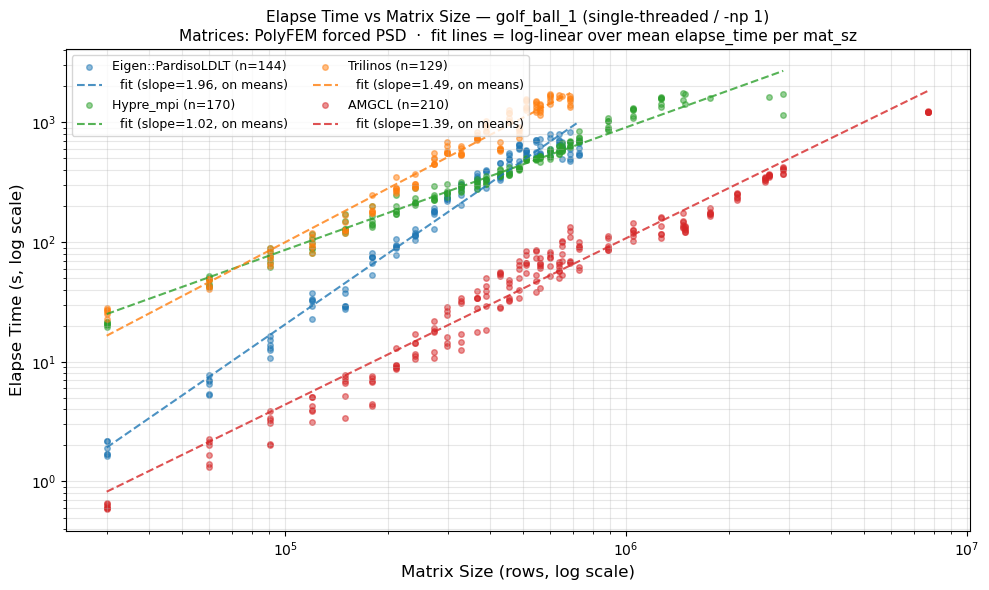

In [15]:
df1 = load_all_logs(os.path.join(BASE, 'golf_ball_1'))
print(f"Group golf_ball_1: {len(df1)} entries")
print(df1.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'elapse_time': 'mean'}))

fig, ax = plot_time_vs_mat_sz(df1, 'Elapse Time vs Matrix Size — golf_ball_1 (single-threaded / -np 1)')
plt.show()

## Group 2: `golf_ball_8` — 8-way parallel

Group golf_ball_8: 773 entries
                   mat_sz                elapse_time
                      min      max count        mean
solver                                              
AMGCL               29988  7704660   210   49.427628
Eigen::PardisoLDLT  29988   727119   144   71.555836
Hypre_mpi           29988  7704660   210   50.169757
Trilinos            29988  7704660   209  107.913715


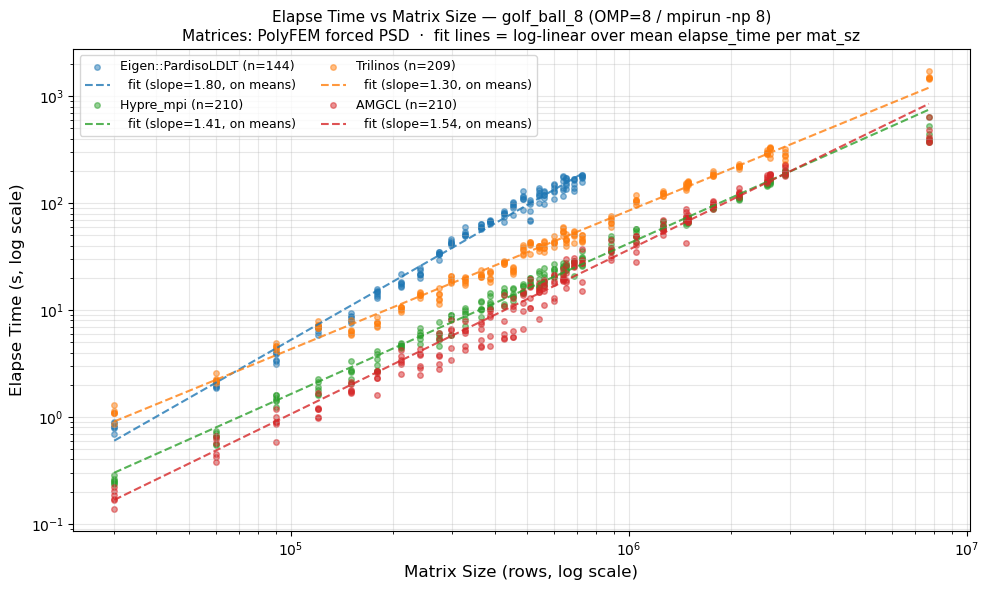

In [16]:
df8 = load_all_logs(os.path.join(BASE, 'golf_ball_8'))
print(f"Group golf_ball_8: {len(df8)} entries")
print(df8.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'elapse_time': 'mean'}))

fig, ax = plot_time_vs_mat_sz(df8, 'Elapse Time vs Matrix Size — golf_ball_8 (OMP=8 / mpirun -np 8)')
plt.show()

### Iteration count vs Matrix Size — `golf_ball_8`

For iterative solvers, the iteration count tells us how convergence degrades as the system grows. Direct solvers (`Eigen::PardisoLDLT`) don't report iterations and are excluded.

Iterative entries in golf_ball_8: 629
          mat_sz                num_iterations              
             min      max count           mean   min     max
solver                                                      
AMGCL      29988  7704660   210       8.542857   4.0    22.0
Hypre_mpi  29988  7704660   210      93.800000  34.0   224.0
Trilinos   29988  7704660   209     114.559809  24.0  1000.0


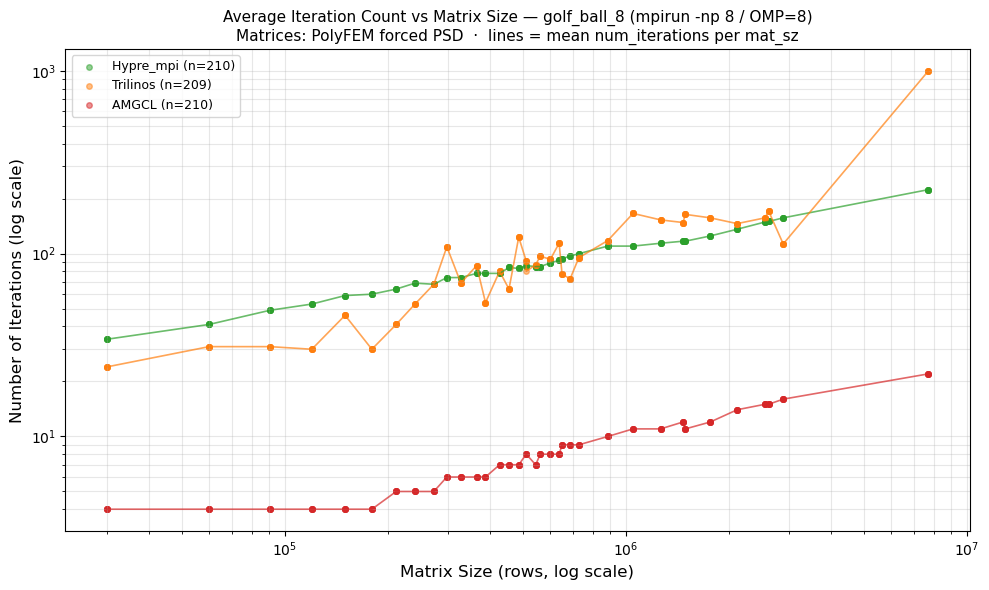

In [17]:
# Iterative solvers only — direct solvers don't report num_iterations
df8_iter = df8[df8['num_iterations'].notna() & (df8['solver'] != 'Eigen::PardisoLDLT')]
print(f"Iterative entries in golf_ball_8: {len(df8_iter)}")
print(df8_iter.groupby('solver').agg({'mat_sz': ['min', 'max', 'count'], 'num_iterations': ['mean', 'min', 'max']}))

fig, ax = plt.subplots(figsize=(10, 6))
for solver in SOLVER_PREFIXES:
    g = df8_iter[df8_iter['solver'] == solver]
    if g.empty:
        continue
    color = SOLVER_COLORS[solver]
    ax.scatter(g['mat_sz'], g['num_iterations'], s=16, alpha=0.5, color=color,
               label=f"{solver} (n={len(g)})")

    # Mean per mat_sz to show trend line
    g_mean = g.groupby('mat_sz')['num_iterations'].mean().reset_index().sort_values('mat_sz')
    if len(g_mean) >= 2:
        ax.plot(g_mean['mat_sz'], g_mean['num_iterations'], '-', color=color,
                linewidth=1.2, alpha=0.7)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Size (rows, log scale)', fontsize=12)
ax.set_ylabel('Number of Iterations (log scale)', fontsize=12)
ax.set_title('Average Iteration Count vs Matrix Size — golf_ball_8 (mpirun -np 8 / OMP=8)\n'
             f'{DATA_SOURCE_NOTE}  ·  lines = mean num_iterations per mat_sz', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()